
# Randomized Experiments & Experimental Design

*A lecture note on why the coin flip is only the first decision in a
randomized experiment — and how to make the rest of them.*

---

## 1. Intro: randomization is necessary, but it isn't sufficient

The [fundamental problem of causal inference](../fundamental-problem-of-causal-inference/tutorial.ipynb)
tutorial showed something powerful: if you randomly assign treatment $T_i$,
you guarantee **ignorability** — $\{Y_i(0), Y_i(1)\} \perp T_i$ — and the
naive difference in observed group means becomes an unbiased estimate of
the **ATE**. Flip a coin per unit, and selection bias is mathematically
zero. Problem solved... right?

Not quite. That tutorial quietly handed you an experiment that was already
*well designed*: hundreds of participants, a simple coin flip, plenty of
statistical power to see the effect. In practice, **you have to design that
experiment before you run it**, and every design choice has consequences
you cannot fix afterward by staring harder at the data:

- **How many units do you need?** Too few, and even a real effect will
  usually look like noise — you'll walk away concluding "no effect" when
  there was one all along.
- **How do you randomize?** A coin flip per unit is the simplest option,
  but grouping units by a covariate first (**blocking**), or randomizing
  whole clusters instead of individuals (**cluster randomization**), can
  change how much you learn from the same budget — for better or worse.
- **How do you know, before spending the money, whether the experiment
  even *could* detect the effect size you care about?**

This tutorial is about the engineering that has to happen *before* the
coin flip: **experimental design**. We'll derive the **power analysis**
formula that tells you exactly how large an experiment needs to be, define
**Type I/II errors** and the alpha/power tradeoff precisely, show why
**stratified (blocked) randomization** can make an experiment more precise
for free, explain why **cluster randomization** silently taxes your sample
size, and then run all of it — design diagnostics included — on a real
randomized experiment: Thornton (2008)'s Malawi HIV testing incentive
trial.

**By the end of this tutorial you'll be able to:**

- Derive, from the sampling distribution of a two-sample mean difference,
  the formula for the sample size needed to detect a given effect at a
  chosen significance level and power — not just look the formula up.
- Explain Type I error ($\alpha$), Type II error ($\beta$), and power
  ($1-\beta$), and reason about the real cost tradeoffs behind choosing
  them.
- Explain why stratified/blocked randomization reduces the variance of a
  treatment-effect estimate, and why cluster randomization increases the
  effective sample size you need (the **design effect**).
- Run a pre-registered-style balance check and a real power/MDE analysis
  on a real experimental dataset, and estimate a real treatment effect.

This assumes you've seen potential outcomes, ATE, and ignorability before
(from the fundamental-problem-of-causal-inference tutorial) — we build on
that vocabulary directly rather than re-deriving it.



## 2. The idea, intuitively

Imagine flipping a coin 10 times and getting 7 heads. Is the coin biased?
Hard to say — 7/10 happens fairly often even from a fair coin, just by
luck. Now flip it 10,000 times and get 7,000 heads. Now you'd bet your
house it's biased. **Nothing about the coin changed between those two
scenarios — only the amount of data you collected before asking the
question.**

Randomized experiments have exactly this problem. A **true** effect can be
sitting right there in your data and still be statistically invisible if
your sample is too small — buried under ordinary random noise. This is not
a hypothetical: it's the single most common reason a well-designed,
correctly-randomized experiment fails to answer its own question.

**The core intuition of this whole tutorial:** whether you can detect an
effect depends on three things pulling against each other —

- **how big the true effect is** (bigger effects are easier to see),
- **how noisy the outcome is** (more variance in the data hides the
  signal), and
- **how much data you collect** (more data averages out the noise).

Statistical **power** is just a name for "the probability my experiment
successfully detects a real effect of a given size, given how noisy my
data is and how many units I collected." Let's see that relationship
directly with a tiny simulation, before writing down any formula: we'll
simulate a *real* effect and repeatedly run a small experiment vs. a large
experiment, and just count how often each one 'catches' the effect.


In [1]:

import numpy as np
import pandas as pd
from scipy import stats

rng = np.random.default_rng(42)

# Ground truth: treatment genuinely raises the outcome mean by 0.05
# (e.g. a 5-percentage-point lift in a binary "did the thing happen?" outcome)
true_effect = 0.05
baseline_rate = 0.50          # control group's true mean
sigma = np.sqrt(baseline_rate * (1 - baseline_rate))  # Bernoulli-ish outcome std

def run_one_experiment(n_per_arm):
    # Simulate one randomized experiment and return the two-sample t-test p-value.
    control = rng.binomial(1, baseline_rate, n_per_arm)
    treated = rng.binomial(1, baseline_rate + true_effect, n_per_arm)
    _, pval = stats.ttest_ind(treated, control)
    return pval

n_sims = 2000
for n_per_arm in [20, 100, 500, 2000]:
    pvals = [run_one_experiment(n_per_arm) for _ in range(n_sims)]
    detection_rate = np.mean(np.array(pvals) < 0.05)
    print(f"n per arm = {n_per_arm:5d}   "
          f"P(detect a real 5pp effect at alpha=0.05) = {detection_rate:.2f}")


n per arm =    20   P(detect a real 5pp effect at alpha=0.05) = 0.05


n per arm =   100   P(detect a real 5pp effect at alpha=0.05) = 0.13


n per arm =   500   P(detect a real 5pp effect at alpha=0.05) = 0.37


n per arm =  2000   P(detect a real 5pp effect at alpha=0.05) = 0.90



Look at that last column. **The exact same true effect (+5 percentage
points) is detected almost never at $n=20$ per arm, and almost always at
$n=2000$ per arm** — nothing about reality changed, only the amount of
data. That detection rate you just estimated by brute-force simulation
*is* statistical power. The rest of this tutorial derives a formula that
tells you the required $n$ directly, instead of having to simulate it.

**Key takeaway: a randomized experiment that is too small doesn't
usually give you a *wrong* answer — it gives you no answer, dressed up as
"no significant effect."** Confusing "underpowered" with "no effect" is
one of the most common misreadings of experimental results in practice,
and design is how you prevent it before you spend a single dollar
collecting data.



## 3. Going deeper: the formal theory of experimental design

### 3.1 Type I and Type II errors

Every hypothesis test we run on an experiment's data can go wrong in two
distinct ways. Let $H_0: \tau = 0$ (no effect) and $H_1: \tau = \delta \neq
0$ (a real effect of size $\delta$).

| | $H_0$ true (no real effect) | $H_1$ true (real effect $\delta$) |
|---|---|---|
| **Reject $H_0$** | **Type I error** (false positive), probability $\alpha$ | Correct: **power** $= 1-\beta$ |
| **Fail to reject $H_0$** | Correct (true negative) | **Type II error** (false negative), probability $\beta$ |

- $\alpha = P(\text{reject } H_0 \mid H_0 \text{ true})$ — the **significance
  level**, chosen by the analyst (conventionally $0.05$). It is the rate at
  which you'll cry "effect!" on pure noise.
- $\beta = P(\text{fail to reject } H_0 \mid H_1 \text{ true, effect } =
  \delta)$ — the **Type II error rate**, a function of the true effect size
  $\delta$, the noise $\sigma$, and the sample size $n$.
- **Power** $= 1 - \beta$ — the probability of correctly detecting a real
  effect of size $\delta$. Conventionally targeted at $0.80$ or $0.90$.

These trade off directly against each other and against sample size:
tightening $\alpha$ (fewer false positives) makes it *harder* to reject
$H_0$, which increases $\beta$ (more false negatives) for a fixed $n$. The
only way to improve both simultaneously is to collect more data, or reduce
noise in the outcome — which is exactly what the rest of this section is
about.

### 3.2 Deriving the power formula for a two-sample mean comparison

Consider an experiment with $n$ units per arm (equal allocation),
continuous outcome $Y$ with common variance $\sigma^2$ in each arm, and
treatment effect $\delta = \mathbb{E}[Y\mid T=1] - \mathbb{E}[Y\mid T=0]$.
The estimator is the difference in sample means,
$\hat\delta = \bar Y_T - \bar Y_C$.

**Step 1 — sampling distribution.** By the Central Limit Theorem, for
large $n$,

$$\bar Y_T \sim \mathcal{N}\!\left(\mu_T, \frac{\sigma^2}{n}\right), \qquad
  \bar Y_C \sim \mathcal{N}\!\left(\mu_C, \frac{\sigma^2}{n}\right),$$

and since the two arms are independent samples,

$$\hat\delta = \bar Y_T - \bar Y_C \sim
  \mathcal{N}\!\left(\mu_T - \mu_C, \ \frac{2\sigma^2}{n}\right).$$

**Step 2 — the test statistic under $H_0$.** Define
$Z = \hat\delta \big/ \sqrt{2\sigma^2/n}$. Under $H_0$ ($\mu_T=\mu_C$),
$Z \sim \mathcal{N}(0,1)$. A two-sided test at level $\alpha$ rejects $H_0$
when $|Z| > z_{1-\alpha/2}$, where $z_{1-\alpha/2}$ is the
$(1-\alpha/2)$-quantile of the standard normal (e.g. $z_{0.975}=1.96$).

**Step 3 — the test statistic under $H_1$.** Now suppose the true effect
is $\delta$. Then $\hat\delta \sim \mathcal{N}(\delta, 2\sigma^2/n)$, so

$$Z = \frac{\hat\delta}{\sqrt{2\sigma^2/n}} \sim
  \mathcal{N}\!\left(\frac{\delta}{\sqrt{2\sigma^2/n}}, \ 1\right).$$

**Step 4 — power is the probability of rejecting, under this shifted
distribution.** Ignoring the (typically negligible) probability of
rejecting in the *wrong* direction,

$$\text{power} = 1-\beta \approx
  P\!\left(Z > z_{1-\alpha/2} \;\middle|\; Z \sim \mathcal{N}\!\left(\frac{\delta}{\sqrt{2\sigma^2/n}}, 1\right)\right)
  = \Phi\!\left(\frac{\delta}{\sqrt{2\sigma^2/n}} - z_{1-\alpha/2}\right),$$

where $\Phi$ is the standard normal CDF. This single line *is* the whole
relationship from the simulation above, written in closed form: power
rises with $\delta$ (bigger effect), falls with $\sigma$ (noisier
outcome), and rises with $n$ (more data).

**Step 5 — solve for $n$.** Set power $= 1-\beta$ and invert:

$$\Phi^{-1}(1-\beta) = \frac{\delta}{\sqrt{2\sigma^2/n}} - z_{1-\alpha/2}
  \quad\Longrightarrow\quad
  \frac{\delta}{\sqrt{2\sigma^2/n}} = z_{1-\alpha/2} + z_{1-\beta}$$

$$\boxed{\ n = \frac{2\sigma^2\left(z_{1-\alpha/2} + z_{1-\beta}\right)^2}{\delta^2}\ }
  \qquad \text{(required } n \text{ per arm)}$$

The same algebra rearranged for $\delta$ gives the **minimum detectable
effect (MDE)** — the smallest true effect a study of size $n$ per arm can
detect at the chosen $\alpha$ and power:

$$\boxed{\ \delta_{\text{MDE}} = \left(z_{1-\alpha/2}+z_{1-\beta}\right)\sqrt{\frac{2\sigma^2}{n}}\ }$$

These two boxed formulas are the two directions of the same question:
*"how big must my sample be"* vs. *"what's the smallest effect my sample
can see."* Every power calculator (G*Power, `statsmodels.stats.power`,
online sample-size calculators) is a wrapper around this derivation, for
whichever test statistic is relevant (means, proportions, rates).

For a **binary outcome** with success probability $p$ under the null,
$\sigma^2 = p(1-p)$ (Bernoulli variance) plugs directly into the same
formula — the algebra above never assumed a continuous outcome, only a
CLT-approximated sampling distribution, which holds for proportions with
reasonably large $n$.

### 3.3 Choosing $\alpha$ and power: a real tradeoff, not a default

$\alpha=0.05$ and power $=0.80$ are conventions, not laws of nature.
The right choice depends on the *cost* of each error type:

- A false positive in a Phase III drug trial ($\alpha$ too loose) can put
  an ineffective, possibly harmful drug on the market — so trials use
  strict $\alpha$ (sometimes $\alpha=0.01$ or stricter after multiple-testing
  correction) and accept the larger, more expensive sample size that
  requires.
- A false negative in an early-stage tech A/B test ($\beta$ too high, i.e.
  underpowered) mostly costs you a missed product improvement — often
  cheaper to tolerate than paying for a much larger experiment, especially
  if you can just run a follow-up test.
- Requiring higher power for a fixed $\delta$ and $\sigma$ mechanically
  requires a larger $n$ — because $z_{1-\beta}$ grows as power increases,
  which directly inflates the numerator of the boxed $n$ formula above.

### 3.4 Stratified (blocked) randomization: free variance reduction

So far we assumed all $n$ units share one variance $\sigma^2$. Suppose
instead a covariate $X$ (e.g. age, baseline risk, store size) is
**prognostic** — predictive of $Y$ regardless of treatment. By the law of
total variance, splitting the population into strata $s = 1,\dots,S$,

$$\sigma^2 = \underbrace{\mathbb{E}_s\left[\text{Var}(Y \mid s)\right]}_{\text{within-stratum variance}}
  + \underbrace{\text{Var}_s\left(\mathbb{E}[Y\mid s]\right)}_{\text{between-stratum variance}}.$$

**Simple randomization** (one coin flip for the whole sample) leaves both
terms in the noise the estimator has to average over. **Stratified
(blocked) randomization** — randomize treatment *within* each stratum
separately, so every stratum gets the same treated/control ratio — and
then estimate the effect controlling for (or within) strata. This removes
the between-stratum term from the effective variance entirely: the
comparison is now, in expectation, only fighting the within-stratum
variance $\mathbb{E}_s[\text{Var}(Y\mid s)] \le \sigma^2$.

Plugging the smaller variance into the boxed formulas from §3.2:
**stratifying on a covariate that predicts $Y$ either (a) shrinks the
required $n$ for the same MDE, or (b) shrinks the MDE for the same $n$ —
for free, with no extra units collected.** The more predictive the
stratifying covariate, the bigger the between-stratum term removed, the
bigger the gain. (Stratifying on a covariate that *doesn't* predict $Y$
costs essentially nothing — the between-stratum term was already ~0 — so
in practice you stratify on any covariate you strongly suspect is
prognostic; there's little downside.)

### 3.5 Cluster randomization and the design effect

Sometimes you cannot randomize individuals independently — a new
classroom curriculum can't be given to *some* students in a room and not
others without contamination; a store-level pricing policy can't vary
customer-by-customer. You're forced to randomize whole **clusters**
(villages, classrooms, stores) instead.

If units within a cluster are correlated — measured by the
**intraclass correlation** $\rho = \text{Corr}(Y_i, Y_j)$ for two units $i,j$
in the same cluster — then $m$ correlated observations carry less
information than $m$ independent ones. The **design effect** quantifies
exactly how much less:

$$\text{DEFF} = 1 + (m-1)\rho, \qquad n_{\text{eff}} = \frac{n}{\text{DEFF}},$$

where $m$ is the average cluster size and $n$ is the total number of
individual units. Even a small $\rho$ (e.g. $0.05$) with moderately large
clusters ($m=50$) inflates DEFF to $1+49(0.05)=3.45$ — meaning you need
**3.45$\times$ as many individual units** as a naive individual-level power
calculation would suggest, to reach the same power. This is why
cluster-randomized trials (common in education and development economics)
are dramatically more expensive per unit of statistical power than
individually randomized ones, and why their standard errors must be
clustered at the randomization level (never at the individual level) or
the reported precision will be badly overstated.



## 4. Visuals: power and MDE as curves

The two boxed formulas from §3.2 are functions of $n$ — so before touching
real data, let's just plot them for an illustrative outcome ($\sigma=0.5$,
a plausible standard deviation for a proportion-like outcome) at the
conventional $\alpha=0.05$: (1) power as a function of $n$ for a couple of
fixed effect sizes, and (2) the MDE as a function of $n$ at 80% power. Both
panels are the *same* algebra, just solved for a different unknown.


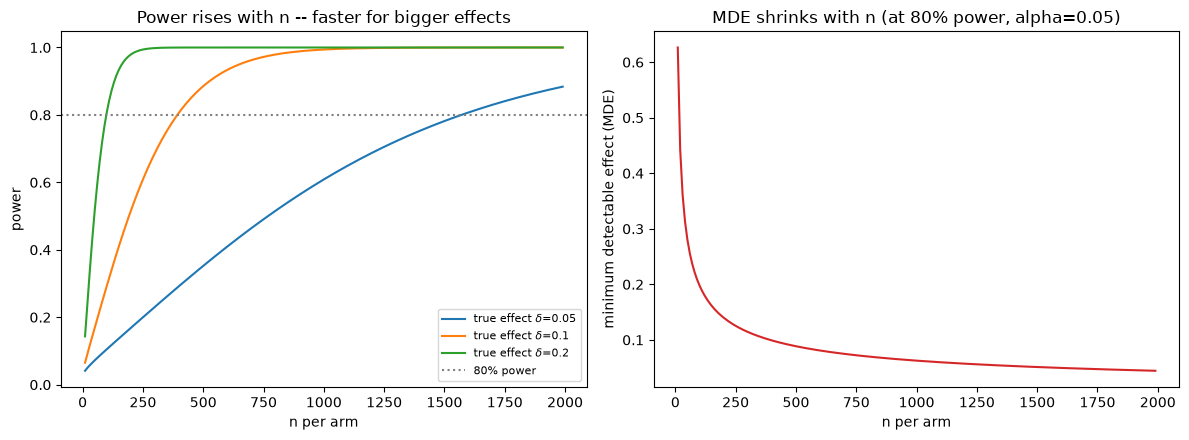

In [2]:

import matplotlib.pyplot as plt
from scipy.stats import norm

alpha = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

def power_of_n(n_per_arm, delta, sigma):
    z_delta = delta / np.sqrt(2 * sigma**2 / n_per_arm)
    return norm.cdf(z_delta - z_alpha)

def mde_of_n(n_per_arm, sigma, power=0.8):
    z_power = norm.ppf(power)
    return (z_alpha + z_power) * np.sqrt(2 * sigma**2 / n_per_arm)

sigma_illustrative = 0.5
n_grid = np.arange(10, 2000, 10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for delta in [0.05, 0.10, 0.20]:
    axes[0].plot(n_grid, [power_of_n(n, delta, sigma_illustrative) for n in n_grid],
                 label=f"true effect $\\delta$={delta}")
axes[0].axhline(0.8, color="gray", linestyle=":", label="80% power")
axes[0].set_xlabel("n per arm"); axes[0].set_ylabel("power")
axes[0].set_title("Power rises with n -- faster for bigger effects")
axes[0].legend(fontsize=8)

axes[1].plot(n_grid, [mde_of_n(n, sigma_illustrative) for n in n_grid], color="tab:red")
axes[1].set_xlabel("n per arm"); axes[1].set_ylabel("minimum detectable effect (MDE)")
axes[1].set_title("MDE shrinks with n (at 80% power, alpha=0.05)")

plt.tight_layout()
plt.savefig("power_mde_illustrative.png", dpi=130)
plt.show()



Two things to notice, both direct consequences of the boxed formulas:
**power climbs steeply at first and then flattens** (each extra unit buys
less and less additional power — diminishing returns), and **the MDE
curve falls as $1/\sqrt{n}$**, so cutting the detectable effect in half
requires **quadrupling** the sample size, not doubling it. This
$1/\sqrt n$ scaling is the single most important practical fact in
experimental design: shrinking the smallest detectable effect gets
expensive fast.

Now let's redo both curves with a real outcome's real variance, from a
real study, and see where that study actually landed.



## 5. Implementation: designing (in hindsight) a real experiment

**Data**: Thornton, R. (2008), *The Demand for, and Impact of, Learning
HIV Status*, American Economic Review 98(5). A randomized field experiment
in rural Malawi (2004): after a free, confidential HIV test, respondents
were randomly assigned a **cash incentive voucher of varying amount**
(0, 50, 100, 200, or 300 Kwacha, converted to USD in this dataset as
`tinc`, ranging $0 to ~$2.84) redeemable *only* if they traveled to a
results center to learn their result. The outcome of interest is `got`:
did the respondent actually return to learn their HIV status. This is a
clean, individually-randomized incentive experiment — exactly the kind of
study where the design questions from §3 matter in practice.


In [3]:

df = pd.read_stata(
    "https://raw.githubusercontent.com/scunning1975/mixtape/master/thornton_hiv.dta"
)
print("Full raw file:", df.shape)

# MainSample flags the analysis sample the original study used (nonmissing
# treatment/outcome, consented, etc.) -- restrict to it like the original paper does.
sub = df[df["MainSample"] == 1].copy()
print("Analysis sample (MainSample == 1):", sub.shape)

sub[["tinc", "any", "got", "age", "male", "mar", "distvct"]].describe().round(3)


Full raw file: (4820, 133)
Analysis sample (MainSample == 1): (2812, 133)


,tinc,any,got,age,male,mar,distvct
count,2812.000,2812.000,2812.000,2812.000,2812.000,2803.000,2812.000
mean,1.007,0.780,0.692,33.385,0.463,0.711,2.016
std,0.899,0.414,0.462,13.652,0.499,0.453,1.265
min,0.000,0.000,0.000,11.000,0.000,0.000,0.033
25%,0.189,1.000,0.000,22.000,0.000,0.000,1.035
50%,0.946,1.000,1.000,32.000,0.000,1.000,1.689
75%,1.891,1.000,1.000,43.000,1.000,1.000,2.796
max,2.837,1.000,1.000,80.000,1.000,1.000,5.192



`tinc` is the randomly assigned incentive **amount** (continuous, $0 to
~$2.84); `any` is 1 for anyone who received a positive incentive and 0 for
the zero-incentive control arm; `got` is the binary outcome (did they
return for results). Confirmed directly from the data: `any` is exactly
`tinc > 0` for every row, and there are five distinct incentive
denominations (`Ti` in Kwacha: 0, 50, 100, 200, 300), individually
randomized *within* villages — 118 of 119 villages contain more than one
distinct incentive amount, so this is **not** a cluster-randomized design
at the village level, even though respondents are naturally grouped into
119 villages.

### 5.1 Was this experiment well designed? The balance check

Just like the fundamental-problem tutorial's "Table 1," we check whether
pre-treatment covariates are balanced across the zero-incentive control
group and the any-incentive group. This is a *design* diagnostic, not
just a formality: with individual-level randomization, imbalance would
suggest either bad luck (expected occasionally) or a broken randomization
procedure.


In [4]:

from scipy import stats

covariates = ["age", "male", "mar", "distvct"]
treat_grp = sub[sub["any"] == 1]
ctrl_grp = sub[sub["any"] == 0]

rows = []
for c in covariates:
    t_mean, c_mean = treat_grp[c].mean(), ctrl_grp[c].mean()
    tstat, pval = stats.ttest_ind(treat_grp[c].dropna(), ctrl_grp[c].dropna(), equal_var=False)
    rows.append({"covariate": c, "any-incentive mean": round(t_mean, 3),
                 "zero-incentive mean": round(c_mean, 3),
                 "diff": round(t_mean - c_mean, 4), "p-value": round(pval, 4)})
balance = pd.DataFrame(rows)
print(f"n(any incentive) = {len(treat_grp)},  n(zero incentive) = {len(ctrl_grp)}\n")
print(balance.to_string(index=False))


n(any incentive) = 2194,  n(zero incentive) = 618

covariate  any-incentive mean  zero-incentive mean    diff  p-value
      age           33.743999            32.108002  1.6359   0.0060
     male            0.461000             0.471000 -0.0101   0.6579
      mar            0.711000             0.709000  0.0021   0.9208
  distvct            2.034000             1.951000  0.0825   0.1416



Three of the four covariates (sex, marital status, distance to the
testing center) balance cleanly. **`age` does not**: the any-incentive
group is about 1.6 years older on average, significant at $p\approx
0.006$ — well below the $\alpha=0.05$ threshold, and not the kind of
borderline p-value you'd casually wave off as one-in-twenty chance noise.
This is exactly the sort of flag a pre-registered design analysis exists
to catch. It doesn't necessarily mean randomization failed (age could
happen to correlate with something structural about who was reachable on
survey days), but it's a real, honest imbalance — the responsible move is
to control for age in the effect regression below (or stratify by an age
block in a re-run of this design), not to ignore it because the headline
effect turns out large anyway.

**This is also the practical case *for* the stratified randomization
covered in §3.4**: had age been used as a blocking variable at
randomization time, this exact imbalance would have been mechanically
impossible, instead of something to notice and correct for after the
fact.

### 5.2 How much statistical power did this study actually have?

The study wasn't designed by us, but we can ask, in hindsight: given the
achieved sample size and the real variance of the outcome, what is the
smallest effect this design *could* reliably (80% power) have detected?
This uses the exact MDE formula derived in §3.2, with $\sigma^2$ taken
from the real Bernoulli variance of `got`, and $n$ taken from the
actual, unequal arm sizes achieved (Kwacha denomination 0 vs. any positive
denomination).


In [5]:

n_treat, n_ctrl = len(treat_grp), len(ctrl_grp)
p_got = sub["got"].mean()
var_got = p_got * (1 - p_got)   # Bernoulli variance, matches the empirical .var() closely

alpha = 0.05
power_target = 0.80
z_alpha = norm.ppf(1 - alpha / 2)
z_power = norm.ppf(power_target)

# Unequal allocation: Var(diff) = sigma^2/n_treat + sigma^2/n_ctrl (exact, no approximation)
se_diff = np.sqrt(var_got / n_treat + var_got / n_ctrl)
mde_achieved = (z_alpha + z_power) * se_diff

print(f"p(got) = {p_got:.3f}  ->  Bernoulli variance = {var_got:.4f}")
print(f"n(any incentive) = {n_treat},  n(zero incentive) = {n_ctrl},  total n = {n_treat + n_ctrl}")
print(f"MDE at alpha=0.05, 80% power, actual allocation = {mde_achieved:.4f} "
      f"({mde_achieved*100:.1f} percentage points)")


p(got) = 0.692  ->  Bernoulli variance = 0.2131
n(any incentive) = 2194,  n(zero incentive) = 618,  total n = 2812
MDE at alpha=0.05, 80% power, actual allocation = 0.0589 (5.9 percentage points)


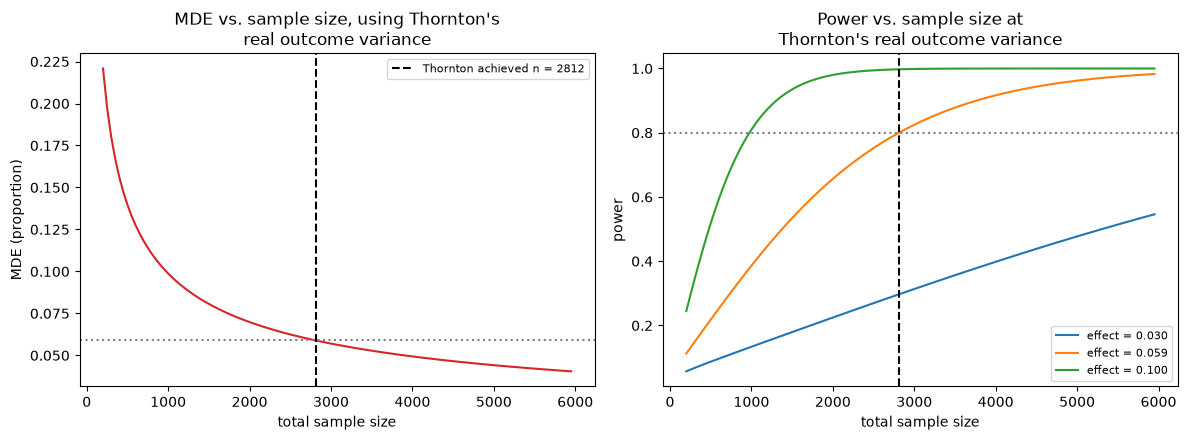

In [6]:

# Power/MDE curves using the REAL outcome variance from Thornton, at the
# actual (unequal) 2194:618 allocation ratio, varying total sample size.
def se_diff_at_total_n(total_n, ratio_treat=n_treat / (n_treat + n_ctrl), sigma2=var_got):
    n_t = total_n * ratio_treat
    n_c = total_n * (1 - ratio_treat)
    return np.sqrt(sigma2 / n_t + sigma2 / n_c)

def mde_at_total_n(total_n):
    return (z_alpha + z_power) * se_diff_at_total_n(total_n)

def power_at_total_n(total_n, delta):
    se = se_diff_at_total_n(total_n)
    return norm.cdf(delta / se - z_alpha)

total_n_grid = np.arange(200, 6000, 50)
achieved_total_n = n_treat + n_ctrl

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(total_n_grid, [mde_at_total_n(n) for n in total_n_grid], color="tab:red")
axes[0].axvline(achieved_total_n, color="black", linestyle="--",
                label=f"Thornton achieved n = {achieved_total_n}")
axes[0].axhline(mde_achieved, color="gray", linestyle=":")
axes[0].set_xlabel("total sample size"); axes[0].set_ylabel("MDE (proportion)")
axes[0].set_title("MDE vs. sample size, using Thornton's\nreal outcome variance")
axes[0].legend(fontsize=8)

for delta in [0.03, mde_achieved, 0.10]:
    axes[1].plot(total_n_grid, [power_at_total_n(n, delta) for n in total_n_grid],
                 label=f"effect = {delta:.3f}")
axes[1].axhline(0.8, color="gray", linestyle=":")
axes[1].axvline(achieved_total_n, color="black", linestyle="--")
axes[1].set_xlabel("total sample size"); axes[1].set_ylabel("power")
axes[1].set_title("Power vs. sample size at\nThornton's real outcome variance")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("thornton_power_curves.png", dpi=130)
plt.show()



With $n\approx2{,}800$ respondents split roughly 78/22 between any-incentive
and zero-incentive arms, this study could reliably (80% power, $\alpha=0.05$)
detect an effect as small as **about 5.9 percentage points** on the
probability of returning for HIV results. That's a genuinely small MDE —
this was a well-powered study for its central question. As we're about to
see, the actual effect Thornton found was far larger than that threshold,
meaning the study had power to spare on the headline comparison (though,
as discussed in §7, that doesn't mean every subgroup or secondary
comparison in the same paper was equally well powered).

### 5.3 Estimating the effect: does the incentive change return rates?


In [7]:

import statsmodels.formula.api as smf

# (a) Any positive incentive vs. none
m_any = smf.ols("got ~ any", data=sub).fit(cov_type="HC1")
ci_any = m_any.conf_int().loc["any"]
print("Effect of ANY positive incentive (vs. $0):")
print(f"  control (zero-incentive) return rate = {m_any.params['Intercept']:.3f}")
print(f"  ATE = {m_any.params['any']:+.3f}   95% CI = [{ci_any[0]:.3f}, {ci_any[1]:.3f}]   "
      f"p = {m_any.pvalues['any']:.2e}\n")

# (b) Continuous incentive amount (dose-response), with village-clustered SEs
# -- clustering is the conservative choice even though randomization was
#    individual-level, since village-level shocks could still correlate errors.
m_dose_robust = smf.ols("got ~ tinc", data=sub).fit(cov_type="HC1")
m_dose_cluster = smf.ols("got ~ tinc", data=sub).fit(cov_type="cluster",
                                                       cov_kwds={"groups": sub["villnum"]})
print("Effect of incentive AMOUNT (dollars), dose-response:")
print(f"  coefficient = {m_dose_robust.params['tinc']:.3f} per dollar of incentive")
print(f"  robust SE (HC1)          = {m_dose_robust.bse['tinc']:.4f}")
print(f"  village-clustered SE     = {m_dose_cluster.bse['tinc']:.4f}  "
      f"({100*(m_dose_cluster.bse['tinc']/m_dose_robust.bse['tinc']-1):+.0f}% vs. HC1 -- "
      f"a real, if modest, design-effect-style penalty from village correlation)")


Effect of ANY positive incentive (vs. $0):
  control (zero-incentive) return rate = 0.341
  ATE = +0.449   95% CI = [0.408, 0.490]   p = 6.50e-102

Effect of incentive AMOUNT (dollars), dose-response:
  coefficient = 0.177 per dollar of incentive
  robust SE (HC1)          = 0.0090
  village-clustered SE     = 0.0111  (+24% vs. HC1 -- a real, if modest, design-effect-style penalty from village correlation)


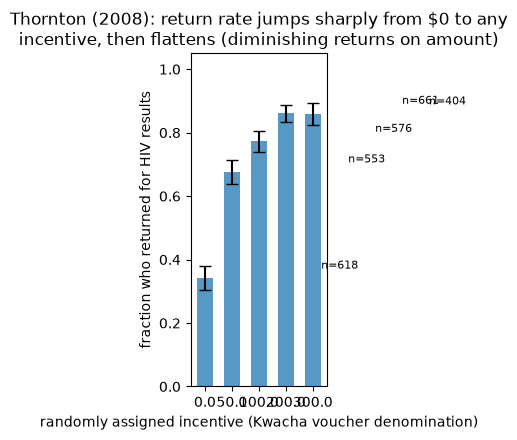

In [8]:

bucket_stats = sub.groupby("Ti")["got"].agg(["mean", "count"]).reset_index()
bucket_stats["se"] = np.sqrt(bucket_stats["mean"] * (1 - bucket_stats["mean"]) / bucket_stats["count"])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(bucket_stats["Ti"].astype(str), bucket_stats["mean"],
       yerr=1.96 * bucket_stats["se"], capsize=4, color="tab:blue", alpha=0.75,
       width=0.6)
for _, row in bucket_stats.iterrows():
    ax.text(str(int(row["Ti"])), row["mean"] + 0.03, f"n={int(row['count'])}",
            ha="center", fontsize=8)
ax.set_xlabel("randomly assigned incentive (Kwacha voucher denomination)")
ax.set_ylabel("fraction who returned for HIV results")
ax.set_title("Thornton (2008): return rate jumps sharply from $0 to any\nincentive, then flattens (diminishing returns on amount)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("thornton_dose_response.png", dpi=130)
plt.show()



**Interpretation.** Going from **no incentive to any incentive** raises
the probability of returning for HIV results by about **45 percentage
points** (34% $\to$ ~78%) — enormous, and nowhere near the ~5.9pp MDE
threshold, so this headline result was never in danger of being an
underpowered null. The **dose-response** (bucket) plot shows *why* the
single "any vs. none" number and the "per-dollar" coefficient tell
different stories: the big jump happens at the *zero-to-positive*
threshold (0 $\to$ 50 Kwacha), and the curve **flattens** at higher
denominations (200 vs. 300 Kwacha are statistically indistinguishable) —
a classic diminishing-returns pattern that a single linear-in-dollars
coefficient partially averages over and partially misses. This is why
Thornton's actual paper reports both the any-incentive contrast and the
dose-response separately, rather than only the single linear slope.

Note also that **village-clustering the standard errors modestly widened
them** relative to heteroskedasticity-robust (HC1) SEs, even though the
incentive amount itself was randomized *within* villages (not at the
village level) — a preview of the design-effect logic from §3.5: any
correlation among units sharing a higher-level grouping (shared testing
staff, shared local rumors about the study, shared travel logistics to the
results center) inflates the true sampling variance beyond what an
i.i.d.-assuming formula reports, so a careful analyst checks both.

One last identification note, worth flagging even though the full
treatment is a separate tutorial: this is an **intent-to-treat (ITT)**-style
estimate — the effect of being *assigned* an incentive amount, not
necessarily of *actually redeeming* it or of learning one's results
through some other channel. If assignment and actual take-up diverge
(non-compliance), the ITT and the effect on those who comply
(sometimes called TOT/LATE, covered in the instrumental-variables
tutorial in this domain) are different quantities and can differ
substantially.



## 6. Use cases

- **Clinical trials**: sample-size/power calculations are a required part
  of every trial protocol submitted to regulators (FDA, EMA) — a trial
  that's underpowered for its primary endpoint can be rejected before it
  even starts enrolling patients.
- **Tech A/B testing**: every serious experimentation platform (product
  experiments at large tech companies, marketing lift tests) runs a
  sample-size/MDE calculator *before* launching a test, to decide how long
  to run it and whether the traffic available can even detect a
  business-relevant effect.
- **Government policy pilots**: pilot programs for social policy (cash
  transfers, job training, tax nudges) use the same power calculations to
  decide how many participants/sites are needed before a pilot can
  credibly inform a scale-up decision.
- **Development economics field experiments**: Banerjee, Duflo, and
  Kremer's Nobel-winning body of work (randomized anti-poverty
  interventions) routinely uses cluster randomization at the
  village/school level for exactly the practical reason in §3.5 —
  individual-level randomization within a village is often logistically or
  ethically impossible — and their published designs explicitly report
  the design effect used to size the study.
- **Online experimentation platforms** (Optimizely, GrowthBook, in-house
  systems): implement §3.2's formula directly as a "minimum detectable
  effect" calculator that product teams consult before launching a test.



## 7. Limitations & debates

- **Multiple comparisons / p-hacking risk.** A single well-powered primary
  outcome (like `got` here) is one thing; real studies often check dozens
  of secondary outcomes and subgroups. At $\alpha=0.05$, checking 20
  independent outcomes yields roughly one false positive *by construction*,
  even with zero true effects anywhere. Pre-registering the primary outcome
  and analysis plan (as modern RCTs increasingly require) is the standard
  defense; correction procedures (Bonferroni, false discovery rate control)
  are the statistical one. The balance check in §5.1 is itself a multiple-
  comparisons situation — checking 4 covariates, expect roughly 1-in-20
  chance of a spurious flag on any one of them, which is part of why we
  didn't over-interpret the `age` imbalance as proof of a broken design.
- **Power and cost/ethics trade off directly.** The MDE formula makes this
  explicit: halving the MDE requires *quadrupling* $n$ (the $1/\sqrt n$
  scaling from §4). For clinical trials, quadrupling $n$ means quadrupling
  the number of patients exposed to an unproven treatment (or an inert
  placebo, denying some patients an effective one) — a real ethical cost,
  not just a budget line. There is no formula that resolves this; it's a
  judgment call made explicit by knowing the numbers, rather than an
  argument for skipping the calculation.
- **Cluster randomization's design effect is easy to underestimate.**
  Analysts sometimes run a cluster-randomized study (village, classroom,
  store) but perform power calculations or standard errors as if
  randomization were individual-level. As §3.5 showed, this can overstate
  precision by a factor of several $\times$ depending on $\rho$ and cluster
  size — a well-documented, still-recurring mistake in field-experiment
  reporting.
- **Non-compliance and Hawthorne effects dilute the estimate you actually
  want.** The Thornton estimate above is an ITT-style effect (§5.3): if
  people don't comply with their assigned incentive, or if simply *being
  observed* in a study changes behavior (the classic "Hawthorne effect"),
  the ITT estimate can meaningfully understate (or in principle overstate)
  the effect of actually receiving the treatment as intended. Recovering
  the effect on compliers specifically (TOT/LATE) requires an
  instrumental-variables argument — flagged here, developed in the
  instrumental-variables tutorial in this domain.
- **Underpowered "false negatives" vs. p-hacked "false positives" — which
  does more damage to a field?** This is a live methodological debate, not
  settled. P-hacked positives get published, cited, and can take years to
  fail to replicate (costly and visible). Underpowered null results are
  often simply never published (file-drawer problem) or wrongly interpreted
  as "no effect exists" rather than "this study couldn't have told either
  way" — a quieter but arguably more pervasive distortion of what a field
  believes is known, precisely because it doesn't look like an error to a
  reader who doesn't check the power calculation.



## 8. References

- Thornton, R. (2008). *The Demand for, and Impact of, Learning HIV
  Status.* American Economic Review 98(5), 1829-1863. (source of the
  `thornton_hiv.dta` dataset used here, via Cunningham's Mixtape data
  repository)
- Cunningham, S. (2021). *Causal Inference: The Mixtape.* Yale University
  Press.
- Duflo, E., Glennerster, R., & Kremer, M. (2007). *Using Randomization in
  Development Economics Research: A Toolkit.* Handbook of Development
  Economics, Vol. 4.
- Gerber, A. S. & Green, D. P. (2012). *Field Experiments: Design,
  Analysis, and Interpretation.* W. W. Norton & Company.
- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral
  Sciences* (2nd ed.). Lawrence Erlbaum Associates.
- Neyman, J. & Pearson, E. S. (1933). *On the Problem of the Most
  Efficient Tests of Statistical Hypotheses.* Philosophical Transactions
  of the Royal Society A, 231. (origin of Type I/II error framework)
